In [ ]:
from google.colab import files
uploaded = files.upload()

Saving invest_dbbb.csv to invest_dbbb (1).csv


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

df = pd.read_csv('/content/invest_dbbb.csv', sep=';')
print("Размер датафрейма:", df.shape)
display(df.head(3))
df.info()


Размер датафрейма: (458370, 51)


,id,date,age,education_level_cd,marital_status_cd,children_cnt,monthly_income_amt,invest_utilization_dt,forts_flg,margin_status_flg,qualified_investor_flg,in_payment_rub_amt,out_payment_rub_amt,uncovered_position_amt,turnover_rus_bon_amt,turnover_rus_sec_amt,turnover_forts_amt,turnover_cur_amt,turnover_etf_amt,turnover_fnd_amt,turnover_opt_amt,turnover_ore_prc_amt,turnover_ore_sel_amt,turnover_tracking_amt,trade_order_rus_sec_cnt,trade_order_rus_bon_cnt,trade_order_forts_cnt,trade_order_cur_cnt,trade_order_etf_cnt,trade_order_fnd_cnt,trade_order_opt_cnt,trade_order_ore_prc_cnt,trade_order_ore_sel_cnt,trade_order_tracking_cnt,portf_total_amt,portf_mex_amt,portf_rus_sec_amt,portf_rus_bon_amt,initial_margin_amt,portf_cur_amt,portf_etf_amt,portf_fnd_amt,portf_opt_amt,portf_ore_amt,ccr_balance_amt,cor_balance_amt,lon_balance_amt,posts,comments,reacts,reads
0,1479787897,20.04.2024,33,NaN,UNM,0.0,31272.0,13.09.2023,1,0,0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12118,11590,7430,3132,0,524,643,428,0,0,-11298.0,541.0,0.0,0.0,0.0,0.0,0.0
1,601760063,01.02.2024,29,GRD,UNM,0.0,6284.0,29.03.2021,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,16505,16164,9693,6465,0,356,0,23,0,0,NaN,8115.0,0.0,0.0,0.0,0.0,0.0
2,61175329,10.02.2024,38,SCH,MAR,0.0,1904.0,05.12.2023,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2069,2055,1859,0,0,9,22,193,0,0,0.0,25.0,NaN,0.0,0.0,0.0,2.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458370 entries, 0 to 458369
Data columns (total 51 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        458370 non-null  int64  
 1   date                      458370 non-null  object 
 2   age                       458370 non-null  int64  
 3   education_level_cd        233460 non-null  object 
 4   marital_status_cd         267030 non-null  object 
 5   children_cnt              410310 non-null  float64
 6   monthly_income_amt        355140 non-null  float64
 7   invest_utilization_dt     458370 non-null  object 
 8   forts_flg                 458370 non-null  int64  
 9   margin_status_flg         458370 non-null  int64  
 10  qualified_investor_flg    458370 non-null  int64  
 11  in_payment_rub_amt        458370 non-null  int64  
 12  out_payment_rub_amt       458370 non-null  int64  
 13  uncovered_position_amt    458370 non-null  i

In [ ]:

df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y', errors='coerce')
df['invest_utilization_dt'] = pd.to_datetime(df['invest_utilization_dt'], format='%d.%m.%Y', errors='coerce')
num_cols = [
    'children_cnt', 'monthly_income_amt', 'in_payment_rub_amt', 'out_payment_rub_amt',
    'uncovered_position_amt', 'turnover_rus_bon_amt', 'turnover_rus_sec_amt', 'turnover_forts_amt',
    'turnover_cur_amt', 'turnover_etf_amt', 'turnover_fnd_amt', 'turnover_opt_amt',
    'turnover_ore_prc_amt', 'turnover_ore_sel_amt', 'turnover_tracking_amt',
    'trade_order_rus_sec_cnt', 'trade_order_rus_bon_cnt', 'trade_order_forts_cnt',
    'trade_order_cur_cnt', 'trade_order_etf_cnt', 'trade_order_fnd_cnt', 'trade_order_opt_cnt',
    'trade_order_ore_prc_cnt', 'trade_order_ore_sel_cnt', 'trade_order_tracking_cnt',
    'portf_total_amt', 'portf_mex_amt', 'portf_rus_sec_amt', 'portf_rus_bon_amt',
    'initial_margin_amt', 'portf_cur_amt', 'portf_etf_amt', 'portf_fnd_amt', 'portf_opt_amt',
    'portf_ore_amt', 'ccr_balance_amt', 'cor_balance_amt', 'lon_balance_amt',
    'posts', 'comments', 'reacts', 'reads'
]
for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
        .str.replace(' ', '', regex=False)
        .astype(float)
    )
df[num_cols].dtypes.head(10)


,0
children_cnt,float64
monthly_income_amt,float64
in_payment_rub_amt,float64
out_payment_rub_amt,float64
uncovered_position_amt,float64
turnover_rus_bon_amt,float64
turnover_rus_sec_amt,float64
turnover_forts_amt,float64
turnover_cur_amt,float64
turnover_etf_amt,float64


In [ ]:
print("\nКоличество пропусков:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nКоличество дубликатов:", df.duplicated().sum())


Количество пропусков:


,0
lon_balance_amt,309867
education_level_cd,224910
marital_status_cd,191340
ccr_balance_amt,167028
monthly_income_amt,103230
children_cnt,48060
comments,19320
posts,19320
reacts,19320
reads,19320



Количество дубликатов: 0


In [ ]:
display(df.describe().T)

,count,mean,min,25%,50%,75%,max,std
id,458370.0,1062470150.582172,42390.0,523467735.0,1053415730.0,1613186539.0,2147202935.0,619260972.499048
date,458370,2024-03-16 12:00:00,2024-02-01 00:00:00,2024-02-23 00:00:00,2024-03-16 12:00:00,2024-04-08 00:00:00,2024-04-30 00:00:00,NaN
age,458370.0,40.533674,18.0,33.0,40.0,47.0,86.0,10.917544
children_cnt,410310.0,0.071507,0.0,0.0,0.0,0.0,5.0,0.353806
monthly_income_amt,355140.0,4511.029242,0.0,1722.0,3143.0,5025.0,156294.0,6157.620522
invest_utilization_dt,458370,2021-10-24 13:53:14.266640384,2018-04-27 00:00:00,2020-10-08 00:00:00,2021-10-25 00:00:00,2023-03-06 00:00:00,2024-02-01 00:00:00,NaN
forts_flg,458370.0,0.530006,0.0,0.0,1.0,1.0,1.0,0.499099
margin_status_flg,458370.0,0.322597,0.0,0.0,0.0,1.0,1.0,0.467471
qualified_investor_flg,458370.0,0.286797,0.0,0.0,0.0,1.0,1.0,0.452266
in_payment_rub_amt,458370.0,234.774529,0.0,0.0,0.0,0.0,1934399.0,5938.801774


In [ ]:
df = df.drop_duplicates()
print("Размер после удаления дубликатов:", df.shape)
df[['age', 'monthly_income_amt', 'children_cnt', 'portf_total_amt']].describe().round(2)

Размер после удаления дубликатов: (458219, 51)


,age,monthly_income_amt,children_cnt,portf_total_amt
count,458219.00,355096.00,410195.00,458219.00
mean,40.54,4511.15,0.07,60590.00
std,10.92,6157.80,0.35,320478.86
min,18.00,0.00,0.00,-942382.00
25%,33.00,1722.00,0.00,1816.00
50%,40.00,3143.00,0.00,8775.00
75%,47.00,5025.00,0.00,36539.50
max,86.00,156294.00,5.00,15318996.00


## **Посмотрим на возраст клиентов**

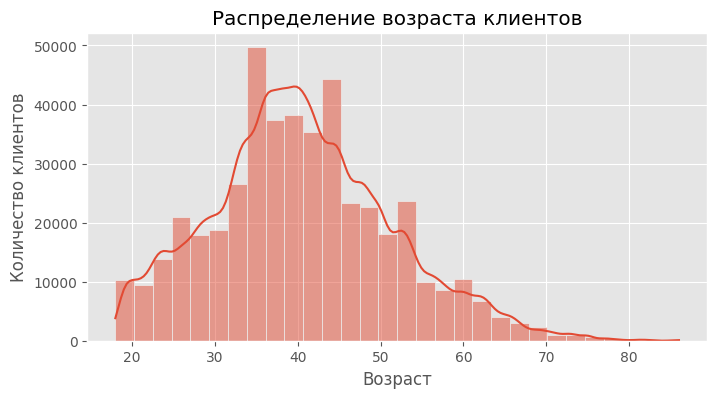

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Распределение возраста клиентов")
plt.xlabel("Возраст")
plt.ylabel("Количество клиентов")
plt.show()


### **Вывод по возрасту клиентов:**
Основная аудитория Т-Инвестиций — это клиенты **32–45 лет**, с пиком активности около 40 лет.
Распределение показывает спад как среди молодежи (<30 лет),
так и среди пожилых (>55 лет), что указывает на приоритетность среднего возраста с опытом и стабильным доходом.



## Посмотрим на активность клиентов на платформе и ее взаимосвязь с доходом




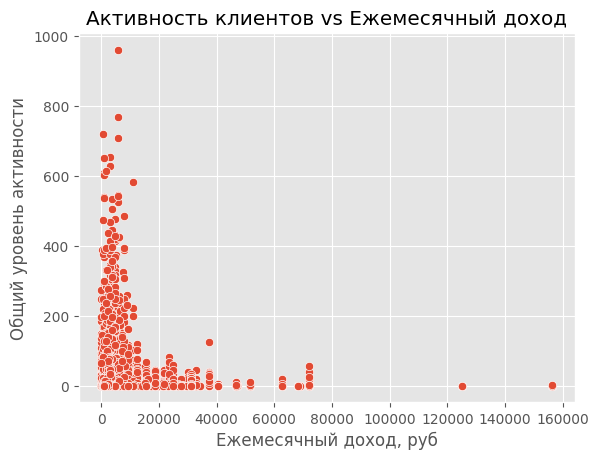

In [ ]:
df['total_activity'] = df['posts'] + df['comments'] + df['reacts'] + df['reads']
sns.scatterplot(data=df.sample(100000, random_state=100), x='monthly_income_amt', y='total_activity')
plt.title("Активность клиентов vs Ежемесячный доход")
plt.xlabel("Ежемесячный доход, руб")
plt.ylabel("Общий уровень активности")
plt.show()

### **Основные выводы по взаимосвязи активности и дохода:**
Большинство клиентов с доходом примерно **до 13 000 рублей** показывают высокую активность (0–600), с редкими всплесками у тех, чей доход превышает 40 000 рублей (до 100).

## **Посмотрим на семейное положение и образование**

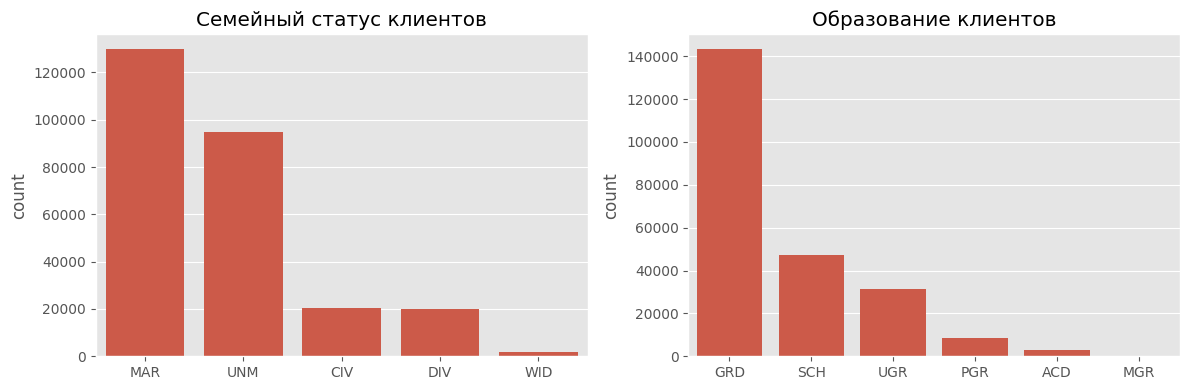

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='marital_status_cd', data=df, ax=axes[0], order=df['marital_status_cd'].value_counts().index)
axes[0].set_title('Семейный статус клиентов')
axes[0].set_xlabel('')

sns.countplot(x='education_level_cd', data=df, ax=axes[1], order=df['education_level_cd'].value_counts().index)
axes[1].set_title('Образование клиентов')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()


### **Основные выводы:**
**По семейному статусу:** Лидируют женатые/замужем (около 130 000) и холостые (около 100 000), в то время как в разведеных и состаящих в гражданском браке намного меньше (около 20 000) , а людей в категории  вдовец/вдова наименьшее количество.

**Образование:** Среди клиентов доминирует категориях тех, кто получил  высшее образование (чуть больше 140 000), следом начальное/среднее (чуть больше 45 000), а катеория людей получивших ученую степень является наименьшей (около 2000 людей).


## **Проанализируем инвестиционную активность клиентов**

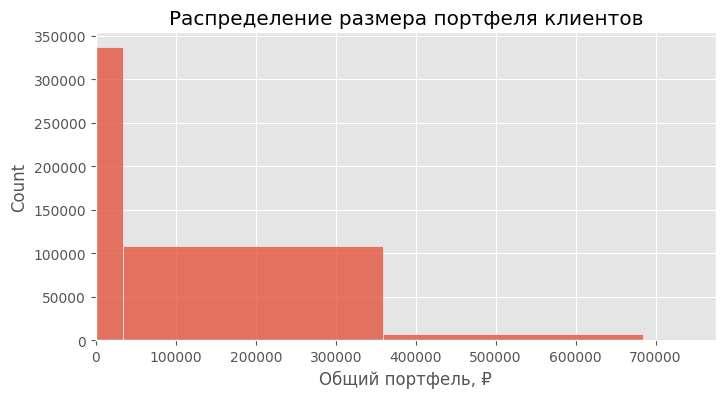

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['portf_total_amt'], bins=50)
plt.title("Распределение размера портфеля клиентов")
plt.xlabel("Общий портфель, ₽")
plt.xlim(0, df['portf_total_amt'].quantile(0.99))
plt.show()


### **Основыные выводы по инвестиционной активности клиентов**


**Размер портфеля:** Основная масса клиентов с портфелем до 30 000 рублей (их околко 340 000), а это в основном начинающие инвесторы с небольшими вложениями.
Умеренная активность до 350 000 рублей (их чуть более 109 000), а вот крупные портфели инвестиций крайне редки (>350 000 рублей), таких клиентов около 5000.
